## Peak performance comparison between Multi-Cube Scan 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 11
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['legend.frameon'] = False
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.5
_MARKERS = ["s", "^", "v", "<", ">", "o", "X"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}


In [2]:
# Select plot parameters

# dtype = "int8"
dtype = "fp16"
tiles = [128]

In [3]:
def add_stats_siso(df, nbytes_out_dtype: int):
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * (df["in_bytes_per_elem"] + nbytes_out_dtype)
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [4]:
PREFIX_PATH = "../../.."

df_copy = pd.read_csv(f"{PREFIX_PATH}/bench_results_copy_{dtype}.csv")
df_copy["S"] = "memcopy (fp16)"
add_stats_siso(df_copy, 2)


df_cast = pd.read_csv(f"{PREFIX_PATH}/bench_results_cast_{dtype}.csv")
df_cast["S"] = "cast (fp16->32)"
add_stats_siso(df_cast, 4)


df_scan = pd.DataFrame()
for tile in tiles:
    df_tmp = pd.read_csv(f"{PREFIX_PATH}/bench_results_mcscan_{tile}_{dtype}.csv")
    df_tmp["S"] = "MCSCAN"
    df_scan = pd.concat([df_scan, df_tmp])

for tile in tiles:
    df_tmp = pd.read_csv(f"{PREFIX_PATH}/bench_results_scan_multi_cube_{tile}_{dtype}.csv")
    df_tmp["S"] = "MCSCANUL1"
    df_scan = pd.concat([df_scan, df_tmp])


add_stats_siso(df_scan, 4)

df = pd.concat([df_copy, df_cast, df_scan])

## Paper plots

/tmp/ipykernel_1551806/989665516.py:9: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='gelemps', palette=palette, **_SNS_PARAMS)
/tmp/ipykernel_1551806/989665516.py:9: UserWarning: The markers list has more values (7) than needed (4), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='gelemps', palette=palette, **_SNS_PARAMS)


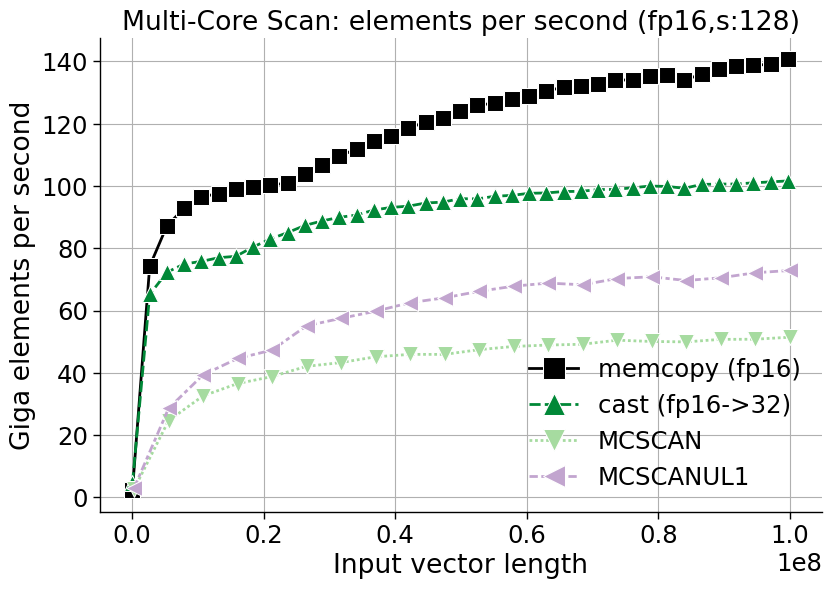

<Figure size 870x627 with 0 Axes>

In [ ]:
palette = [### Colorbrewer colors
"black",
"#008837",
"#a6dba0",
"#c2a5cf",
"#7b3294",]

ax = sns.lineplot(data=df, x='size', y='gelemps', palette=palette, **_SNS_PARAMS)

ax.set_title(f"Multi-Core Scan: elements per second ({dtype},s:128)")
ax.set_xlabel("Input vector length")
ax.set_ylabel("Giga elements per second")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()
plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/mcscan_mcscanul1_gelemsps_{dtype}.png")
plt.show()
plt.clf()

/tmp/ipykernel_1551806/70079141.py:10: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)
/tmp/ipykernel_1551806/70079141.py:10: UserWarning: The markers list has more values (7) than needed (4), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)


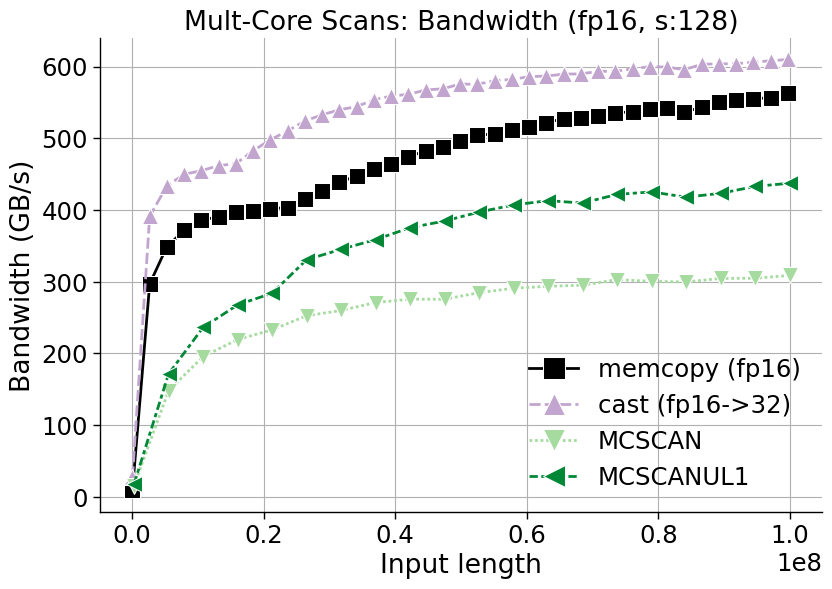

<Figure size 870x627 with 0 Axes>

In [ ]:
palette = [### Colorbrewer colors
"black",
"#c2a5cf",
"#a6dba0",
"#008837",
"#7b3294",]

ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)

ax.set_title(f"Mult-Core Scans: Bandwidth ({dtype}, s:128)")
ax.set_xlabel("Input length")
ax.set_ylabel("Bandwidth (GB/s)")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/mcscan_mcscanul1_bw_{dtype}.png")
plt.show()
plt.clf()


In [8]:
max_size = df["size"].max()
df[df["size"] >= 99 * 1e6].head(20)

,operator,dtype,size,density,outputsize,time_us,S,in_bytes_per_elem,mem_bytes,gelemps,bw_gbps
38,copy_fp16,fp16,99696640,NaN,99696640,708.89,memcopy (fp16),2,398786560,140.637673,562.550692
38,cast_fp16,fp16,99696640,NaN,99696640,980.94,cast (fp16->32),2,598179840,101.633780,609.802679
19,mcscan_128_fp16,fp16,99942400,NaN,99942400,1943.09,MCSCAN,2,599654400,51.434777,308.608659
19,scan_multi_cube_128_fp16,fp16,99942400,NaN,99942400,1371.48,MCSCANUL1,2,599654400,72.871934,437.231604
